# Notebook 4: Grid Tree Data to EnMAP Image Pixels

This is the fourth notebook in the sequence for the HRS Botany project.

In it we will grid the cleaned tree data by it's overlapping EnMAP image pixels. 


__Notebook Inputs:__
- Plot Dataset (_data/plots.csv_)
- Cleaned and merged Tree Dataset (_data/trees.csv_)
- Trimmed EnMAP tiffs and sidecar metadata JSONs 

__Notebook Outputs:__
- Gridded Species Presence-Absence geojsons by EnMAP Pixel  (_data/output_tables/{plot_id}/{enmap_image_id}/presence_absence.geojson_)
- Gridded Species Counts geojsons by EnMAP Pixel  (_data/output_tables/{plot_id}/{enmap_image_id}/counts.geojson_)


In [2]:
from shapely import wkt

from hrs_botany.tree_gridder import TreeEnmapGridder

import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
trees_gdf = gpd.read_file("data/trees.gpkg")
trees_gdf.gbif_taxon_key = trees_gdf.gbif_taxon_key.fillna(-1)
trees_gdf.gbif_taxon_key = trees_gdf.gbif_taxon_key.astype(int).astype(str)
plots_df = pd.read_csv("data/plots.csv", index_col=0)
plots_df['geometry'] = plots_df['geometry'].apply(wkt.loads)
plots_gdf = gpd.GeoDataFrame(plots_df, geometry='geometry', crs="EPSG:4326")

In [4]:

enmap_dir = "./data/enmap_downloads/enmap_downloads_20250708"
output_table_root = "./data/output_tables/20250809"

gridder = TreeEnmapGridder(trees_gdf, plots_gdf, enmap_scene_root=enmap_dir, output_table_root=output_table_root)


In [4]:
gridder.process_all_scenes(
    mode="presence_absence",
    overwrite=True,
)

gridder.process_all_scenes(
    mode="counts",
    overwrite=True,
)

In [5]:
gridder.get_species_options(plot_id="f1")

,gbif_taxon_key,common_name,scientific_name
0,2683909,Coast redwood,Sequoia sempervirens
1,2685796,Douglas-fir,Pseudotsuga menziesii
2,2876032,California hazelnut,Corylus cornuta
3,2878124,Shreve’s oak,Quercus parvula
4,2880791,Coast live oak,Quercus agrifolia
5,2882802,Madrone,Arbutus menziesii
6,3024146,Loquat,Eriobotrya japonic
7,3176787,Blue-gum eucalyptus,Eucalyptus globulus
8,3189835,Big-leaf maple,Acer macrophyllum
9,3906623,Tanoak,Notholithocarpus densiflorus


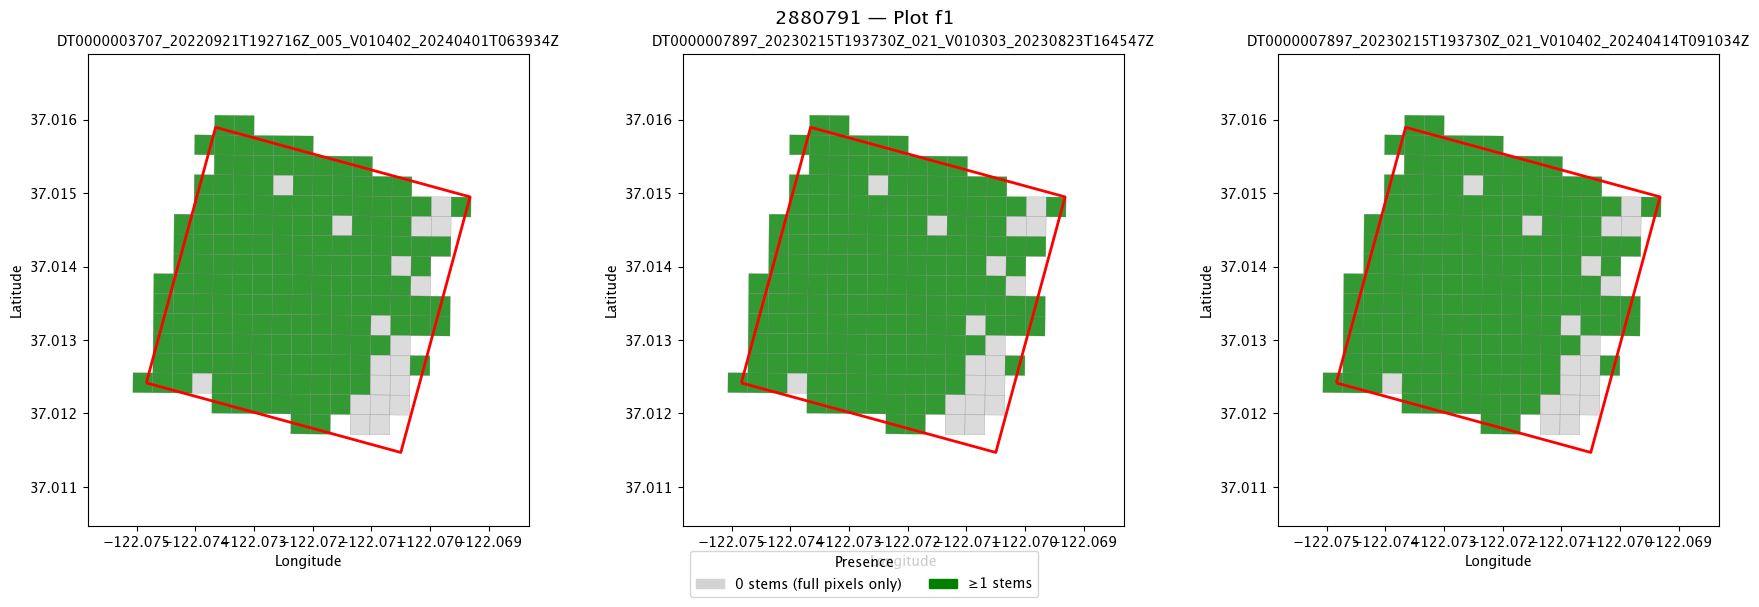

In [6]:

gridder.plot_species_grid(
    plot_id="f1",
    species="2880791",
)
plt.show()

In [5]:
gridder.get_species_options(plot_id="0063")

,gbif_taxon_key,common_name,scientific_name
0,2683936,incense cedar,Calocedrus decurrens (Torr.) Florin
1,2685580,white fir,Abies concolor (Gord. & Glend.) Lindl. ex Hild...
2,2685796,Douglas-fir,Pseudotsuga menziesii
3,2687201,mountain hemlock,Tsuga mertensiana (Bong.) Carrière
4,2879984,canyon live oak,Quercus chrysolepis Liebm.
5,5284989,sugar pine,Pinus lambertiana Douglas
6,5285053,Ponderosa pine,Pinus ponderosa


In [7]:
gridder.get_species_options(plot_id="0084")

,gbif_taxon_key,common_name,scientific_name
0,2877951,None,Quercus spp.
1,2878266,blue oak,Quercus douglasii Hook. & Arn.
2,2878384,interior live oak,Quercus wislizeni A. DC.
3,2882505,sticky whiteleaf manzanita,Arctostaphylos viscida Parry
4,3039459,None,Frangula californica
5,3039477,redberry buckthorn,Rhamnus crocea Nutt.
6,3189813,California buckeye,Aesculus californica (Spach) Nutt.
7,5285255,California foothill pine,Pinus sabiniana Douglas ex Douglas


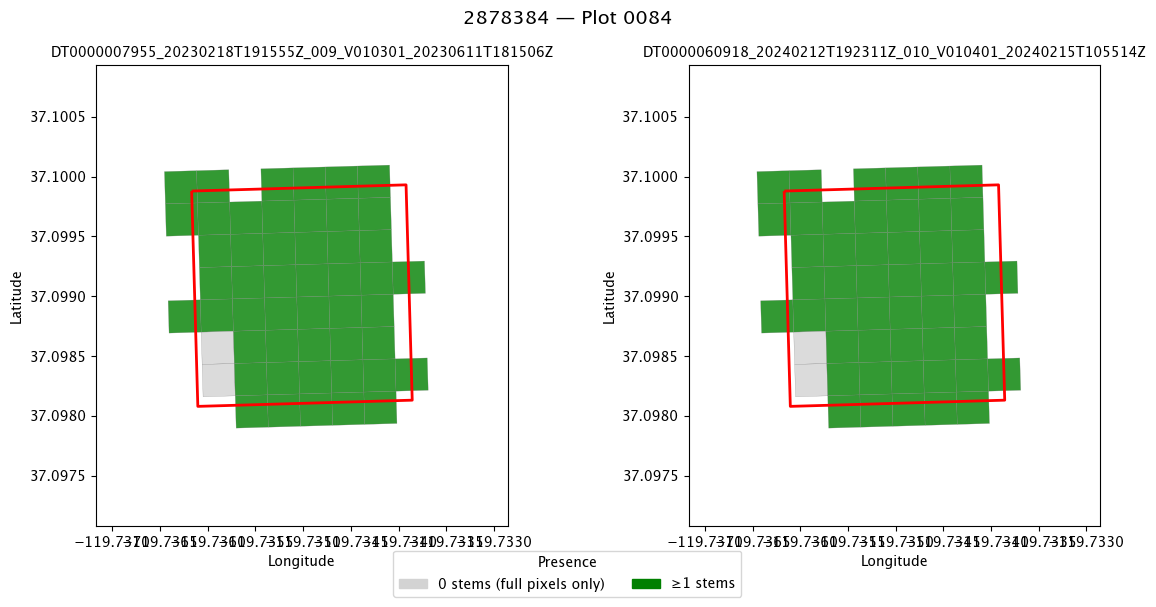

In [8]:

gridder.plot_species_grid(
    plot_id="0084",
    species="2878384",
)
plt.show()

In [9]:
gridder.get_species_options(plot_id="0059")

,gbif_taxon_key,common_name,scientific_name
0,2685796,Douglas-fir,Pseudotsuga menziesii
1,2687201,mountain hemlock,Tsuga mertensiana (Bong.) Carrière
2,2877951,None,Quercus spp.
3,2879260,Oregon white oak,Quercus garryana Douglas ex Hook.
4,5284989,sugar pine,Pinus lambertiana Douglas
5,5285053,Ponderosa pine,Pinus ponderosa


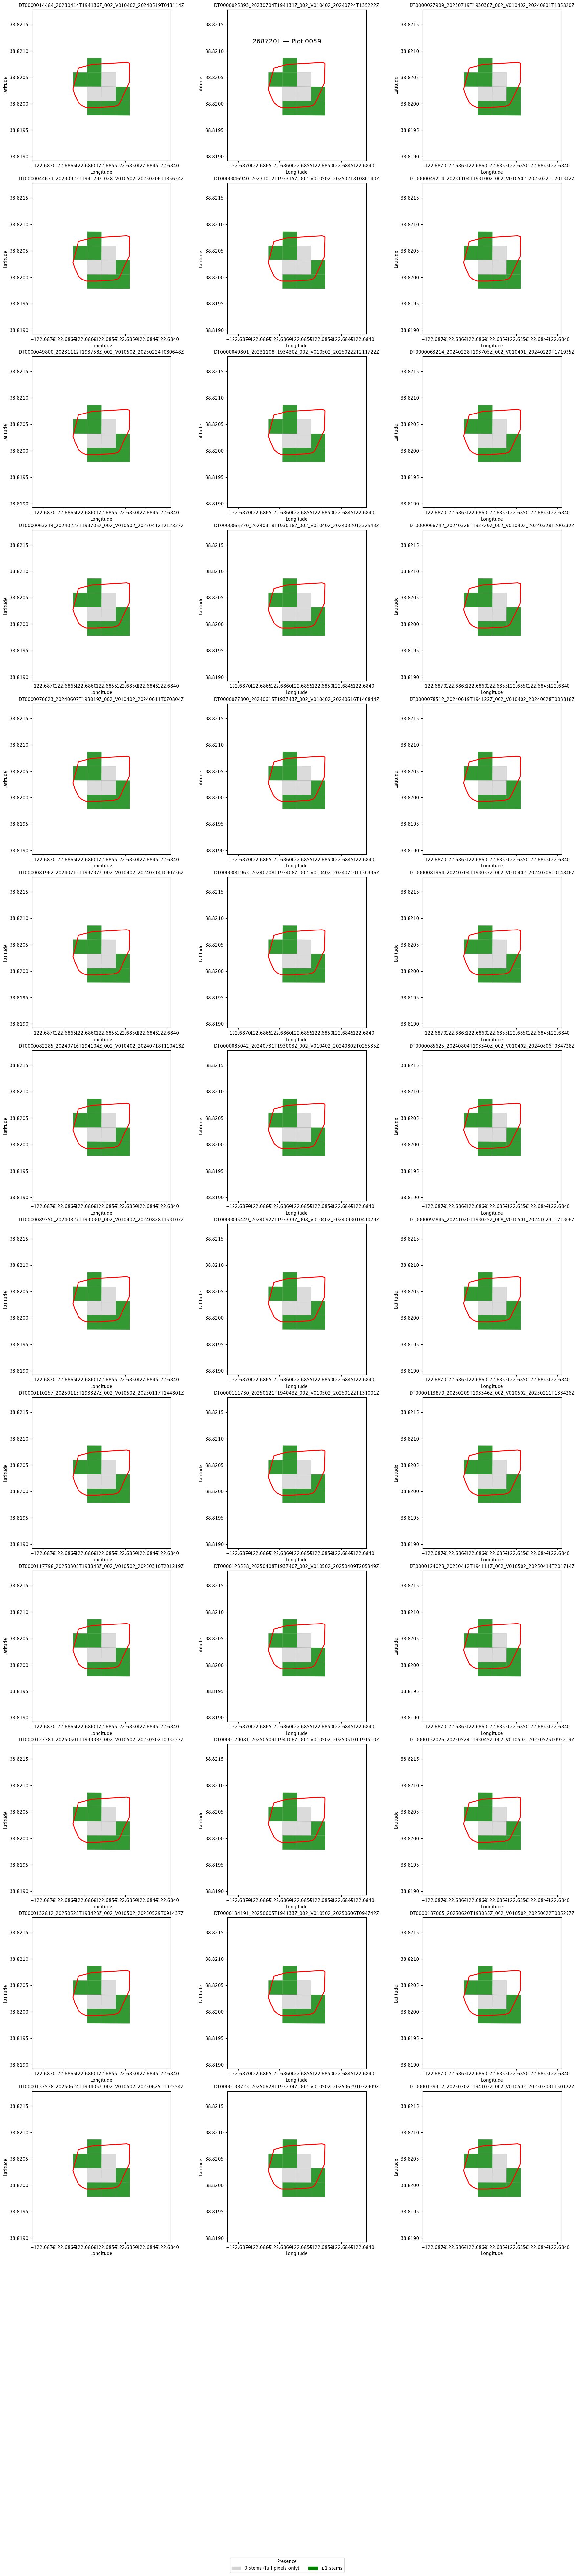

In [10]:

gridder.plot_species_grid(
    plot_id="0059",
    species="2687201",
)
plt.show()